# IMPORTS


In [36]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Layer, MultiHeadAttention, Dense, LayerNormalization, 
    Dropout, Input, Embedding, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# HYPERPARAMETERS


In [37]:
vocab_size = 12000
MAX_LEN = 1500         
embedding_dim = 200   

#  LOAD DATA


In [38]:
df = pd.read_csv("/kaggle/input/nn-26-review-sentiment-classification/train.csv")
df = df.drop('id', axis=1)
df = df.drop_duplicates()

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['review'].value_counts()}")

Dataset shape: (6999, 2)

Class distribution:
review
Very good    2469
Excellent    2335
Good         1024
Bad           647
Very bad      524
Name: count, dtype: int64


# SPLIT DATA

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    df['text'], 
    df['review'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['review'],
    shuffle=True
)

In [40]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

y_train_cat = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_val_cat = ohe.transform(y_val.values.reshape(-1, 1))

num_classes = len(ohe.categories_[0])
print(f"Number of classes: {num_classes}")
print(f"Classes: {ohe.categories_[0]}")

Number of classes: 5
Classes: ['Bad' 'Excellent' 'Good' 'Very bad' 'Very good']


# TRANSFORMER ENCODER BLOCK

In [41]:
class TransformerEncoder(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, rate_l2=0.01, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# POSITIONAL ENCODING


In [42]:
def get_positional_encoding(max_seq_len, embed_dim):
    def get_angles(pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    angle_rads = get_angles(
        np.arange(max_seq_len)[:, np.newaxis],
        np.arange(embed_dim)[np.newaxis, :],
        embed_dim
    )
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

# BUILD TRANSFORMER MODEL

In [43]:
def build_transformer_model(vocab_size, embed_dim, max_seq_len, embedding_matrix,
                            num_encoder_layers, num_heads, ff_dim, dropout_rate,
                            num_classes, embed_trainable, l2_reg):
    
    input_ids = Input(shape=(max_seq_len,), dtype=tf.int32, name="input_ids")
    
    embedding_layer = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=embed_trainable,
        name="glove_embeddings"
    )
    x = embedding_layer(input_ids)
    
    pos_encoding = get_positional_encoding(max_seq_len, embed_dim)
    x = x + pos_encoding
    
    for i in range(num_encoder_layers):
        x = TransformerEncoder(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate,
            rate_l2=l2_reg,
            name=f"transformer_block_{i}"
        )(x)  
    
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax', kernel_regularizer=l2(l2_reg))(x)
    
    model = Model(inputs=input_ids, outputs=output)
    return model

# EMBEDDINGS

In [44]:
glove_path = "/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.200d.txt"
embeddings_index = {}

with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

#  TOKENIZE TEXT

In [45]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')

In [46]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))
hits = 0
misses = 0

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
        misses += 1

In [47]:
y_train_cat = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_val_cat = ohe.transform(y_val.values.reshape(-1, 1))

In [48]:
model = build_transformer_model(
    vocab_size=vocab_size,           
    embed_dim=embedding_dim,             
    max_seq_len=MAX_LEN,          
    embedding_matrix=embedding_matrix, 
    num_encoder_layers=2,        
    num_heads=4,                 
    ff_dim=128,                  
    dropout_rate=0.3,
    num_classes=num_classes,
    embed_trainable=False,        
    l2_reg=0.01                  
)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embeddings (Embedding)    │ (None, 1500, 200)      │     2,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_2 (Add)                     │ (None, 1500, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 1500, 200)      │       694,928 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 1500, 200)      │       694,928 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 200)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,803,045 (14.51 MB)

 Trainable params: 1,403,045 (5.35 MB)

 Non-trainable params: 2,400,000 (9.16 MB)

# compile

In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
# Better learning rate schedule
callbacks = [  tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,      
    min_lr=1e-7,
    verbose=1
)
,tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,      
    restore_best_weights=True
)]

# fit funtion 

In [51]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [52]:
history=model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,  
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 207ms/step - accuracy: 0.1859 - loss: 2.4898 - val_accuracy: 0.0921 - val_loss: 1.8697 - learning_rate: 0.0010
Epoch 2/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.1317 - loss: 1.8328 - val_accuracy: 0.1464 - val_loss: 1.6985 - learning_rate: 0.0010
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.2601 - loss: 1.6545 - val_accuracy: 0.0921 - val_loss: 1.6414 - learning_rate: 0.0010
Epoch 4/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.1078 - loss: 1.6312 - val_accuracy: 0.0750 - val_loss: 1.6242 - learning_rate: 0.0010
Epoch 5/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.1455 - loss: 1.6250 - val_accuracy: 0.3336 - val_loss: 1.6128 - learning_rate: 0.0010
Epoch 6/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 179ms/step - accuracy: 0.1339 - loss: 1.6154 - val_accuracy: 0.1464 - val_loss: 1.6113 - learning_rate: 0.0010
Epoch 7/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 179ms/step - accura

# eval

In [53]:
y_train_pred = model.predict(X_train_pad)
y_train_pred_classes = np.argmax(y_train_pred, axis=1)
y_train_true = np.argmax(y_train_cat, axis=1)

y_val_pred = model.predict(X_val_pad)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step


In [54]:
print("TRAINING SET PERFORMANCE")
print(classification_report(y_train_true, y_train_pred_classes, target_names=ohe.categories_[0]))
print("*"*100)
print("VALIDATION SET PERFORMANCE")
print(classification_report(y_val_true, y_val_pred_classes, target_names=ohe.categories_[0]))

TRAINING SET PERFORMANCE
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00       518
   Excellent       0.00      0.00      0.00      1868
        Good       0.00      0.00      0.00       819
    Very bad       0.00      0.00      0.00       419
   Very good       0.35      1.00      0.52      1975

    accuracy                           0.35      5599
   macro avg       0.07      0.20      0.10      5599
weighted avg       0.12      0.35      0.18      5599

****************************************************************************************************
VALIDATION SET PERFORMANCE
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00       129
   Excellent       0.00      0.00      0.00       467
        Good       0.00      0.00      0.00       205
    Very bad       0.00      0.00      0.00       105
   Very good       0.35      1.00      0.52       494

    accuracy                    

#  VISUALIZATIONS


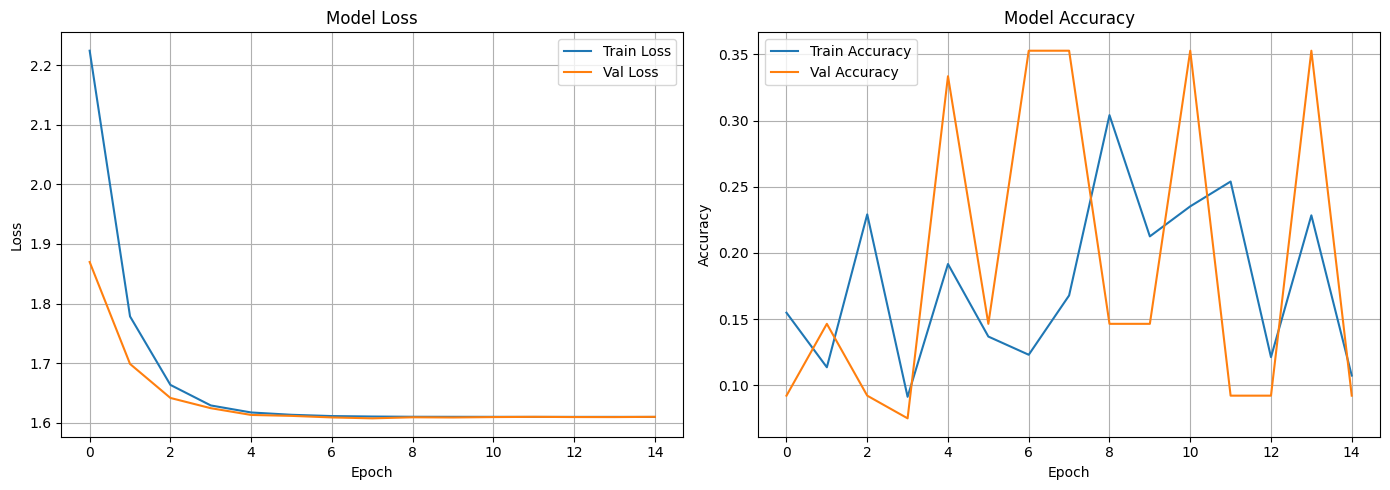

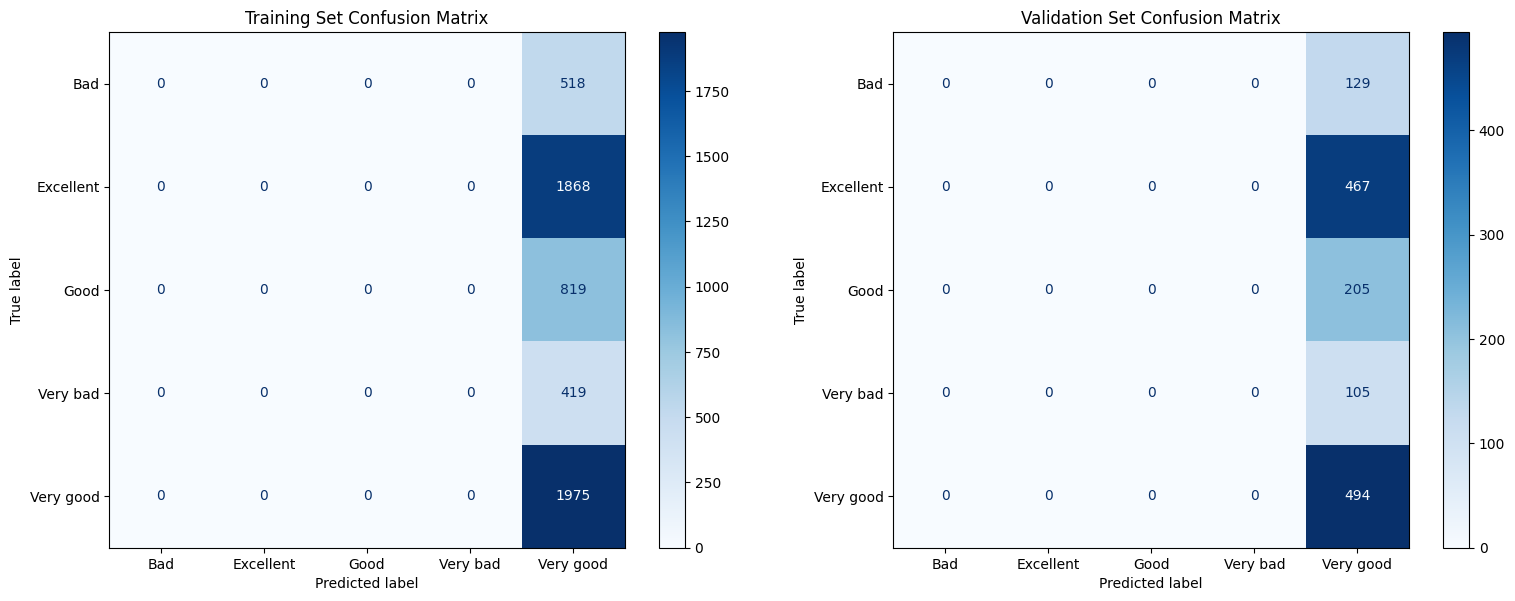

In [55]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plotting Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_train_true, y_train_pred_classes,
    display_labels=ohe.categories_[0], 
    cmap=plt.cm.Blues,
    ax=axes[0]
)
axes[0].set_title("Training Set Confusion Matrix")

# Validation Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_val_true, y_val_pred_classes,
    display_labels=ohe.categories_[0],  
    cmap=plt.cm.Blues,
    ax=axes[1]
)
axes[1].set_title("Validation Set Confusion Matrix")

plt.tight_layout()
plt.show()

# testing

In [56]:
test_df = pd.read_csv("/kaggle/input/nn-26-review-sentiment-classification/test.csv")
test_ids = test_df['id']

X_test_seq = tokenizer.texts_to_sequences(test_df['text'])
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

test_predictions = model.predict(X_test_pad)
test_pred_classes = np.argmax(test_predictions, axis=1)

test_pred_labels = ohe.categories_[0][test_pred_classes]

submission = pd.DataFrame({
    'id': test_ids,
    'review': test_pred_labels
})

submission.to_csv('submission.csv', index=False)

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step
